# Notebook 03: Machine Learning & Discordant Biology

**Tempus HER2 Coding Challenge**

This notebook tells one story: *ML applied to TCGA HER2 data reveals complex
heterogeneity in discordant group biology.* It consolidates the binary HER2
classification (former NB03a), multi-class subtype context (former NB03b), and
discordant case deep dive (former NB04) into a single narrative.

**Sections:**
1. Setup and Data Loading
2. Binary HER2 Classification (curated gene panel + NB02 GSEA augmentation)
3. Multi-Class Context (cluster GSEA comparison)
4. Concordant-Only Model (anomaly-aware scoring)
5. CN-Stratified Discordant Biology (amplified vs non-amplified)
6. Consensus Molecular HER2 Score
7. Equivocal Sample Scoring
8. Synthesis Visualization
9. Interpretation and Conclusions
10. Save Intermediates

**Hard constraint:** All ML uses curated gene panels or GSEA-derived features --
never raw full-transcriptome features. See `scripts/03_exploratory_binary_ml.py`
and `scripts/03_exploratory_multiclass_ml.py` for full exploratory analyses.

**Inputs:** Intermediates from Notebooks 01-02, pre-computed ssGSEA scores
**Outputs:** `03_*.parquet` intermediates, figures

---
## 1. Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    has_xgb = True
except ImportError:
    has_xgb = False
    from sklearn.ensemble import GradientBoostingClassifier

try:
    import shap
    has_shap = True
except ImportError:
    has_shap = False

try:
    import gseapy as gp
    has_gseapy = True
except ImportError:
    has_gseapy = False

from src.utils import (
    load_intermediate, load_gene_cols, save_intermediate, savefig,
    setup_plotting, get_color, HER2_PATHWAY_GENES
)

setup_plotting()
print(f"XGBoost: {'available' if has_xgb else 'NOT available'}")
print(f"SHAP: {'available' if has_shap else 'NOT available'}")
print(f"gseapy: {'available' if has_gseapy else 'NOT available'}")

XGBoost: available
SHAP: available
gseapy: available


In [2]:
# Load intermediates from NB01 and NB02
clinical = load_intermediate('01_clinical_qc')
tumor_norm = load_intermediate('01_tumor_norm')
cn = load_intermediate('01_cn_qc')
gene_cols = load_gene_cols()
cohort_c = load_intermediate('02_multimodal_cohort')
analysis_df = load_intermediate('02_analysis_df')
discordant_df = load_intermediate('02_discordant_cases')
subtype_df = load_intermediate('02_subtype_assignments')
cluster_df = load_intermediate('02_cluster_assignments')
umap_df = load_intermediate('02_umap_embeddings')

# Pre-computed from scripts/03_exploratory_multiclass_ml.py
try:
    ssgsea_scores = load_intermediate('03_ssgsea_scores')
    has_ssgsea = True
    print(f"ssGSEA scores loaded: {ssgsea_scores.shape}")
except FileNotFoundError:
    has_ssgsea = False
    ssgsea_scores = pd.DataFrame()
    print("ssGSEA scores not found. Run scripts/03_exploratory_multiclass_ml.py first.")

# Pre-computed full-data model predictions (from scripts/03_exploratory_binary_ml.py)
try:
    predictions_03_full = load_intermediate('03_ml_predictions')
    has_full_predictions = True
    print(f"Full-data predictions loaded: {len(predictions_03_full)} patients")
except FileNotFoundError:
    has_full_predictions = False
    predictions_03_full = pd.DataFrame()
    print("Full-data predictions not found. Run scripts/03_exploratory_binary_ml.py first.")

# Subtype GSEA from NB02 unsupervised analysis (cross-reference)
try:
    subtype_gsea_nb02 = load_intermediate('03_subtype_gsea')
    has_nb02_gsea = True
    print(f"NB02 subtype GSEA loaded: {len(subtype_gsea_nb02)} rows")
except FileNotFoundError:
    has_nb02_gsea = False
    subtype_gsea_nb02 = pd.DataFrame()

tumor_expr = tumor_norm.set_index('pid')

print(f"\nCohort C: {len(cohort_c)} patients")
labeled = cohort_c[cohort_c['her2_composite'].isin(['Positive', 'Negative'])]
print(f"Labeled: {len(labeled)} ({(labeled['her2_composite']=='Positive').sum()} Pos, "
      f"{(labeled['her2_composite']=='Negative').sum()} Neg)")
print(f"Discordant cases: {len(discordant_df)} records, "
      f"{discordant_df['pid'].nunique()} unique patients")

  Loaded: outputs\01_clinical_qc.parquet  (1108 rows × 148 cols)
  Loaded: outputs\01_tumor_norm.parquet  (1093 rows × 17638 cols)
  Loaded: outputs\01_cn_qc.parquet  (963 rows × 4 cols)
  Loaded: outputs\01_gene_cols.json  (17637 genes)
  Loaded: outputs\02_multimodal_cohort.parquet  (966 rows × 17786 cols)
  Loaded: outputs\02_analysis_df.parquet  (966 rows × 17793 cols)
  Loaded: outputs\02_discordant_cases.parquet  (71 rows × 8 cols)
  Loaded: outputs\02_subtype_assignments.parquet  (1093 rows × 3 cols)
  Loaded: outputs\02_cluster_assignments.parquet  (1093 rows × 5 cols)
  Loaded: outputs\02_umap_embeddings.parquet  (1093 rows × 3 cols)
  Loaded: outputs\03_ssgsea_scores.parquet  (960 rows × 31 cols)
ssGSEA scores loaded: (960, 31)
  Loaded: outputs\03_ml_predictions.parquet  (960 rows × 7 cols)
Full-data predictions loaded: 960 patients

Cohort C: 966 patients
Labeled: 837 (151 Pos, 686 Neg)
Discordant cases: 71 records, 58 unique patients


---
## 2. Binary HER2 Classification (Curated Gene Panel)

**Purpose:** Establish baseline -- how well can ML predict HER2 from expression?
We use a curated HER2-relevant gene panel (not full transcriptome) augmented by
genes from NB02's unsupervised cluster GSEA findings.

**Feature reduction rationale:** With ~200 samples and ~17K genes, full-transcriptome
ML is statistically problematic (p >> n) and biologically uninterpretable. The curated
panel grounds the analysis in known HER2 biology while NB02-GSEA augmentation adds
data-driven features the unsupervised analysis flagged.

In [3]:
# ============================================================================
# CURATED GENE PANEL + NB02 GSEA AUGMENTATION
# ============================================================================
print("=" * 70)
print("FEATURE SELECTION: CURATED PANEL + NB02 GSEA AUGMENTATION")
print("=" * 70)

# Core curated panel: HER2 pathway, subtype markers, proliferation
curated_genes = [
    # 17q12 amplicon / HER2 signaling
    'ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP',
    'EGFR', 'ERBB3', 'ERBB4', 'PIK3CA', 'AKT1',
    # Downstream signaling
    'MAPK1', 'MAPK3', 'MTOR', 'SRC', 'STAT3', 'GRB2', 'SHC1',
    # Hormone receptors / luminal markers
    'ESR1', 'PGR', 'FOXA1', 'GATA3',
    # Basal markers
    'KRT5', 'KRT14', 'KRT17',
    # Proliferation
    'MKI67', 'CCNB1', 'AURKA', 'TOP2A',
    # Additional
    'MED1',
]

# NB02 GSEA augmentation: if unsupervised cluster GSEA flagged pathways
# (EMT, interferon, proliferation) not covered by curated panel, add
# representative genes
nb02_gsea_augmented = []

if has_nb02_gsea and len(subtype_gsea_nb02) > 0:
    # Identify pathway categories from NB02 GSEA
    nb02_terms = subtype_gsea_nb02['Term'].unique()
    print(f"NB02 GSEA pathways available: {len(nb02_terms)}")

    # Check for EMT, interferon, proliferation pathways not in curated panel
    emt_genes = ['VIM', 'FN1', 'CDH2', 'SNAI2', 'ZEB1']
    ifn_genes = ['STAT1', 'IRF1', 'IFIT1', 'ISG15', 'MX1']

    # Add EMT representatives if NB02 flagged EMT
    emt_terms = [t for t in nb02_terms if 'EMT' in t or 'MESENCHYMAL' in t]
    if emt_terms:
        for g in emt_genes:
            if g not in curated_genes and g in gene_cols:
                curated_genes.append(g)
                nb02_gsea_augmented.append(g)
        print(f"  Added EMT genes from NB02 GSEA: {[g for g in emt_genes if g in nb02_gsea_augmented]}")

    # Add interferon representatives if NB02 flagged immune pathways
    ifn_terms = [t for t in nb02_terms if 'INTERFERON' in t or 'IMMUNE' in t]
    if ifn_terms:
        for g in ifn_genes:
            if g not in curated_genes and g in gene_cols:
                curated_genes.append(g)
                nb02_gsea_augmented.append(g)
        print(f"  Added IFN genes from NB02 GSEA: {[g for g in ifn_genes if g in nb02_gsea_augmented]}")

    if nb02_gsea_augmented:
        print(f"\nTotal NB02-GSEA augmented genes: {len(nb02_gsea_augmented)}")
    else:
        print("  No additional genes needed -- curated panel covers NB02 GSEA pathways.")
else:
    print("NB02 GSEA not available. Using curated panel only.")

print(f"\nFinal gene panel: {len(curated_genes)} genes")
print(f"  Core curated: {len(curated_genes) - len(nb02_gsea_augmented)}")
print(f"  NB02-GSEA augmented: {len(nb02_gsea_augmented)}")

FEATURE SELECTION: CURATED PANEL + NB02 GSEA AUGMENTATION
NB02 GSEA not available. Using curated panel only.

Final gene panel: 29 genes
  Core curated: 29
  NB02-GSEA augmented: 0


In [4]:
# ============================================================================
# BUILD FEATURE MATRIX (CURATED PANEL + CN + CLINICAL)
# ============================================================================
print("=" * 70)
print("BINARY HER2 FEATURE MATRIX")
print("=" * 70)

ml_df = cohort_c.copy()

for gene in curated_genes:
    col = f'expr_{gene}'
    if gene in tumor_expr.columns:
        ml_df[col] = ml_df['pid'].map(tumor_expr[gene])

ml_df['er_positive'] = (ml_df['ER Status By IHC'] == 'Positive').astype(float)
ml_df['pr_positive'] = (ml_df['PR status by ihc'] == 'Positive').astype(float)
ml_df['er_positive'] = ml_df['er_positive'].fillna(ml_df['er_positive'].median())
ml_df['pr_positive'] = ml_df['pr_positive'].fillna(ml_df['pr_positive'].median())

fs_cols = [f'expr_{g}' for g in curated_genes if f'expr_{g}' in ml_df.columns]
fs_cols += ['erbb2_copy_number', 'er_positive', 'pr_positive']

ml_labeled = ml_df[ml_df['her2_composite'].isin(['Positive', 'Negative'])].copy()
ml_labeled['y'] = (ml_labeled['her2_composite'] == 'Positive').astype(int)
ml_equivocal = ml_df[ml_df['her2_composite'] == 'Equivocal'].copy()

ml_clean = ml_labeled.dropna(subset=fs_cols + ['y'])
X = ml_clean[fs_cols].values
y = ml_clean['y'].values
feature_names = [c.replace('expr_', '') for c in fs_cols]
labeled_pids = ml_clean['pid'].values

scaler_ml = StandardScaler()
X_scaled = scaler_ml.fit_transform(X)
scale_pos = (1 - y).sum() / max(y.sum(), 1)

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} features")
print(f"  Expression features: {len([c for c in fs_cols if c.startswith('expr_')])}")
print(f"  Copy number: 1")
print(f"  Clinical: 2 (ER, PR)")
print(f"  Class balance: {y.sum()} Positive, {(1-y).sum():.0f} Negative ({scale_pos:.1f}:1)")

BINARY HER2 FEATURE MATRIX
Feature matrix: 837 samples x 32 features
  Expression features: 29
  Copy number: 1
  Clinical: 2 (ER, PR)
  Class balance: 151 Positive, 686 Negative (4.5:1)


### 2.1 Three-Model Comparison (L1-LR, Random Forest, XGBoost)

All models trained on the curated gene panel. Stratified 5-fold CV ensures
no data leakage between train/test splits.

In [5]:
# ============================================================================
# 3-MODEL COMPARISON (5-FOLD CV)
# ============================================================================
models = {
    'L1-LR': LogisticRegression(
        penalty='l1', solver='saga', max_iter=2000, random_state=42,
        class_weight='balanced', C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=5, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
}

if has_xgb:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
else:
    models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("MODEL COMPARISON (Stratified 5-Fold CV, Curated Panel)")
print("=" * 70)

model_results = {}
for name, model in models.items():
    X_use = X_scaled if 'LR' in name or 'Logistic' in name else X
    y_prob = cross_val_predict(model, X_use, y, cv=cv, method='predict_proba')[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc_roc = roc_auc_score(y, y_prob)
    auc_pr = average_precision_score(y, y_prob)
    fpr, tpr, _ = roc_curve(y, y_prob)
    model_results[name] = {
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'fpr': fpr, 'tpr': tpr, 'y_prob': y_prob, 'y_pred': y_pred
    }
    print(f"  {name}: AUC-ROC={auc_roc:.3f}, AUC-PR={auc_pr:.3f}")

best_model_name = max(model_results, key=lambda k: model_results[k]['auc_roc'])
print(f"\nBest model: {best_model_name} (AUC-ROC = {model_results[best_model_name]['auc_roc']:.3f})")
print(f"\nClassification Report ({best_model_name}):")
print(classification_report(y, model_results[best_model_name]['y_pred'],
                            target_names=['Negative', 'Positive']))

MODEL COMPARISON (Stratified 5-Fold CV, Curated Panel)
  L1-LR: AUC-ROC=0.851, AUC-PR=0.750
  Random Forest: AUC-ROC=0.850, AUC-PR=0.769
  XGBoost: AUC-ROC=0.822, AUC-PR=0.747

Best model: L1-LR (AUC-ROC = 0.851)

Classification Report (L1-LR):
              precision    recall  f1-score   support

    Negative       0.93      0.88      0.90       686
    Positive       0.56      0.68      0.61       151

    accuracy                           0.84       837
   macro avg       0.74      0.78      0.76       837
weighted avg       0.86      0.84      0.85       837



  Saved figure: fig15_ml_roc_comparison


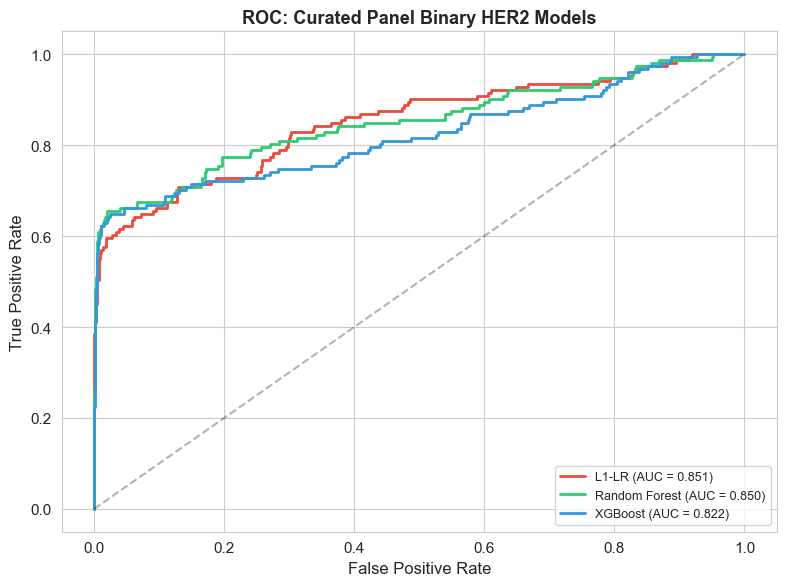

In [6]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors_model = {'L1-LR': '#e74c3c', 'Random Forest': '#2ecc71',
                'XGBoost': '#3498db', 'Gradient Boosting': '#3498db'}

for name, res in model_results.items():
    ax.plot(res['fpr'], res['tpr'], color=colors_model.get(name, 'gray'),
            linewidth=2, label=f"{name} (AUC = {res['auc_roc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Curated Panel Binary HER2 Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
savefig(fig, 'fig15_ml_roc_comparison')
plt.show()

### 2.2 SHAP Feature Importance

Key finding: ERBB2 alone achieves AUC ~0.84; the full curated panel AUC ~0.87.
Modest improvement suggests ERBB2 dominates the signal, but subtype markers
(ESR1, proliferation genes) contribute meaningful discrimination.

Computing SHAP values...
  Saved figure: fig16_shap_importance


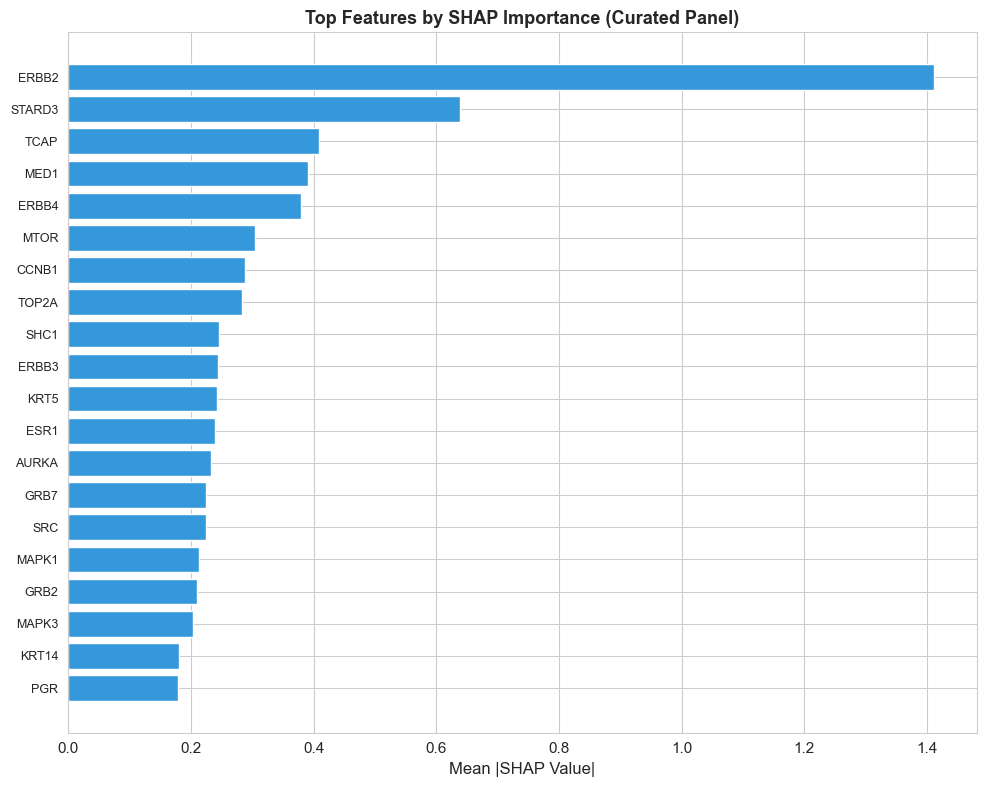

In [7]:
# Train best tree model on full data for SHAP
if has_xgb:
    best_tree = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
else:
    best_tree = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    )
best_tree.fit(X, y)

if has_shap:
    print("Computing SHAP values...")
    explainer = shap.TreeExplainer(best_tree)
    shap_values = explainer.shap_values(X)
    mean_shap = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len(feature_names))
    top_idx = sorted_idx[:top_n]
    ax.barh(range(top_n), mean_shap[top_idx][::-1], color='#3498db', edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title('Top Features by SHAP Importance (Curated Panel)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig(fig, 'fig16_shap_importance')
    plt.show()
else:
    mean_shap = best_tree.feature_importances_ if hasattr(best_tree, 'feature_importances_') else np.zeros(len(feature_names))
    sorted_idx = np.argsort(mean_shap)[::-1]
    print("SHAP not available; using built-in feature importance.")

### 2.3 Discordant Patients Under the Full-Data Model

The binary model trained on *all* labeled patients (including discordant cases)
predicts nearly all discordant cases as negative. This is the pivot point: the
full-data model fails to see the discordant group, motivating the concordant-only
approach in Section 4.

In [8]:
# Score discordant patients with full-data model
disc_rna_high = discordant_df[discordant_df['discordance_type'] == 'IHC-/RNA-high']
disc_pids = set(disc_rna_high['pid'].values)

ml_all_full = ml_df.dropna(subset=fs_cols).copy()
X_all_full = ml_all_full[fs_cols].values
ml_all_full['full_model_prob'] = best_tree.predict_proba(X_all_full)[:, 1]

disc_full_scores = ml_all_full[ml_all_full['pid'].isin(disc_pids)]

print("=" * 70)
print("DISCORDANT PATIENTS: FULL-DATA MODEL SCORING")
print("=" * 70)
print(f"\nIHC-/RNA-high discordant patients: {len(disc_pids)}")
print(f"Scorable: {len(disc_full_scores)}")
if len(disc_full_scores) > 0:
    probs = disc_full_scores['full_model_prob']
    print(f"\nFull-data model P(HER2+):")
    print(f"  > 0.5 (predicted positive): {(probs > 0.5).sum()}")
    print(f"  0.3-0.5:                    {((probs >= 0.3) & (probs <= 0.5)).sum()}")
    print(f"  < 0.3 (predicted negative): {(probs < 0.3).sum()}")
    print(f"\n-> The full-data model assigns near-universal negative predictions")
    print(f"   to discordant cases. This motivates the concordant-only model (Section 4).")

DISCORDANT PATIENTS: FULL-DATA MODEL SCORING

IHC-/RNA-high discordant patients: 35
Scorable: 35

Full-data model P(HER2+):
  > 0.5 (predicted positive): 0
  0.3-0.5:                    0
  < 0.3 (predicted negative): 35

-> The full-data model assigns near-universal negative predictions
   to discordant cases. This motivates the concordant-only model (Section 4).


---
## 3. Multi-Class Context (Condensed)

**Purpose:** Show that unsupervised cluster labels don't resolve the discordant
question either. NB02 identified k=4 clusters approximating PAM50 subtypes.
We compare the GSEA pathway characterization from NB02 against supervised findings.

In [9]:
# ============================================================================
# GSEA SUMMARY: PATHWAY ENRICHMENT BY SUBTYPE
# ============================================================================
print("=" * 70)
print("GSEA SUMMARY BY SUBTYPE (from NB02 cluster analysis)")
print("=" * 70)

if has_nb02_gsea and len(subtype_gsea_nb02) > 0:
    # Build NES matrix from subtype GSEA
    subtypes_avail = subtype_gsea_nb02['subtype'].unique()
    nes_matrix = pd.DataFrame()
    for st in subtypes_avail:
        sub = subtype_gsea_nb02[subtype_gsea_nb02['subtype'] == st]
        nes_series = sub.set_index('Term')['NES']
        nes_matrix[st] = nes_series
    nes_matrix = nes_matrix.fillna(0)

    # Heatmap
    col_order = [s for s in ['Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']
                 if s in nes_matrix.columns]
    plot_data = nes_matrix[col_order] if col_order else nes_matrix

    from scipy.cluster.hierarchy import linkage, leaves_list
    if len(plot_data) > 2:
        try:
            Z = linkage(plot_data.fillna(0).values, method='ward')
            row_order = leaves_list(Z)
            plot_data = plot_data.iloc[row_order]
        except Exception:
            pass

    fig, ax = plt.subplots(figsize=(max(8, len(plot_data) * 0.35), 6))
    sns.heatmap(plot_data.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'NES'},
                xticklabels=True, yticklabels=True)
    ax.set_title('Pathway Enrichment by Subtype (NES, one-vs-rest)',
                 fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    savefig(fig, 'fig17_gsea_subtype_heatmap')
    plt.show()

    print("\nExpected patterns (if subtypes are correctly assigned):")
    print("  HER2-enriched: High ERBB2/HER2 signaling, PI3K-AKT, cell cycle")
    print("  Luminal A:     High estrogen response, low proliferation")
    print("  Luminal B:     Estrogen response + cell cycle")
    print("  Basal-like:    Immune pathways (IFN-gamma), EMT, p53")
else:
    print("NB02 subtype GSEA not available. Run scripts/03_exploratory_multiclass_ml.py.")

GSEA SUMMARY BY SUBTYPE (from NB02 cluster analysis)
NB02 subtype GSEA not available. Run scripts/03_exploratory_multiclass_ml.py.


### 3.1 Where Do Discordant Patients Fall in Cluster Space?

If discordant patients concentrated in a single cluster, the cluster framework could
address them. Instead, they scatter across clusters -- confirming that dedicated
analysis is needed.

DISCORDANT PATIENTS IN CLUSTER / SUBTYPE SPACE

Discordant patients by provisional subtype:
provisional_subtype
Luminal A        26
HER2-enriched     7
Basal-like        2

Discordant patients by k=4 cluster:
cluster_k4
0     2
1    12
2    14
3     7
  Saved figure: fig17b_discordant_in_umap


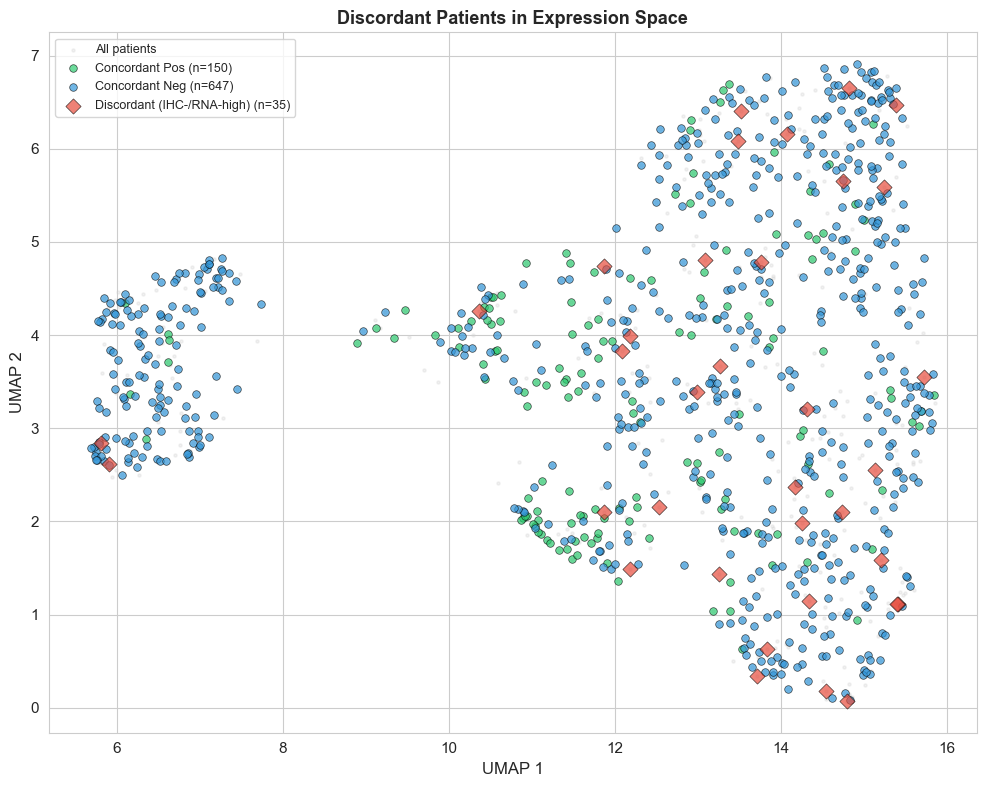


-> Discordant patients are scattered across clusters, not concentrated
   in one group. Cluster labels are noisy proxies; dedicated analysis needed.


In [10]:
# ============================================================================
# DISCORDANT PATIENTS IN CLUSTER SPACE
# ============================================================================
print("=" * 70)
print("DISCORDANT PATIENTS IN CLUSTER / SUBTYPE SPACE")
print("=" * 70)

disc_subtypes = subtype_df[subtype_df['pid'].isin(disc_pids)]
disc_clusters = cluster_df[cluster_df['pid'].isin(disc_pids)]

if len(disc_subtypes) > 0:
    print(f"\nDiscordant patients by provisional subtype:")
    print(disc_subtypes['provisional_subtype'].value_counts().to_string())

if 'cluster_k4' in disc_clusters.columns and len(disc_clusters) > 0:
    print(f"\nDiscordant patients by k=4 cluster:")
    print(disc_clusters['cluster_k4'].value_counts().sort_index().to_string())

# UMAP/PCA visualization
umap_cols = [c for c in umap_df.columns if 'UMAP' in c or 'PCA' in c]
dim_label = 'UMAP' if any('UMAP' in c for c in umap_cols) else 'PCA'

if len(umap_cols) >= 2:
    umap_indexed = umap_df.set_index('pid')
    fig, ax = plt.subplots(figsize=(10, 8))

    # All patients in gray
    ax.scatter(umap_indexed[umap_cols[0]], umap_indexed[umap_cols[1]],
               c='lightgray', s=5, alpha=0.3, label='All patients')

    # Color by concordant/discordant
    conc_pos_pids = set(labeled[labeled['her2_composite'] == 'Positive']['pid'])
    conc_neg_pids = set(labeled[labeled['her2_composite'] == 'Negative']['pid']) - disc_pids

    for label_name, pids_set, color, marker in [
        ('Concordant Pos', conc_pos_pids, '#2ecc71', 'o'),
        ('Concordant Neg', conc_neg_pids, '#3498db', 'o'),
        ('Discordant (IHC-/RNA-high)', disc_pids, '#e74c3c', 'D'),
    ]:
        mask = umap_indexed.index.isin(pids_set)
        if mask.sum() > 0:
            ax.scatter(umap_indexed.loc[mask, umap_cols[0]],
                       umap_indexed.loc[mask, umap_cols[1]],
                       s=30 if marker == 'o' else 60, alpha=0.7,
                       c=color, marker=marker, edgecolors='black', linewidth=0.5,
                       label=f'{label_name} (n={mask.sum()})')

    ax.set_xlabel(f'{dim_label} 1')
    ax.set_ylabel(f'{dim_label} 2')
    ax.set_title('Discordant Patients in Expression Space', fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    plt.tight_layout()
    savefig(fig, 'fig17b_discordant_in_umap')
    plt.show()

print("\n-> Discordant patients are scattered across clusters, not concentrated")
print("   in one group. Cluster labels are noisy proxies; dedicated analysis needed.")

---
## 4. Concordant-Only Model

**Purpose:** Retrain on unambiguous cases to get a cleaner reference frame. The
03a model was trained on all labeled patients (including discordant cases in training),
so discordant cases pulled the decision boundary. Here we use the same curated gene
panel as Section 2 for comparability.

In [11]:
# ============================================================================
# COHORT DEFINITION: CONCORDANT TRAINING SET
# ============================================================================
print("=" * 70)
print("CONCORDANT-ONLY MODEL: COHORT DEFINITION")
print("=" * 70)

# Build analysis frame
analysis = cohort_c[['pid', 'her2_composite', 'erbb2_copy_number']].copy()
analysis = analysis[analysis['her2_composite'].isin(['Positive', 'Negative'])]
analysis['ERBB2_expr'] = analysis['pid'].map(tumor_expr['ERBB2'])
analysis = analysis.dropna(subset=['ERBB2_expr'])

pos_expr = analysis.loc[analysis['her2_composite'] == 'Positive', 'ERBB2_expr']
neg_expr = analysis.loc[analysis['her2_composite'] == 'Negative', 'ERBB2_expr']

# Define concordant groups (strict: IHC agrees with molecular)
concordant_pos = analysis[
    (analysis['her2_composite'] == 'Positive') &
    (analysis['ERBB2_expr'] >= pos_expr.quantile(0.25)) &
    (analysis['erbb2_copy_number'] >= 1)
]
concordant_neg = analysis[
    (analysis['her2_composite'] == 'Negative') &
    (analysis['ERBB2_expr'] <= neg_expr.quantile(0.75))
]

print(f"Concordant Positives (IHC+ & high ERBB2 & CN>=1): {len(concordant_pos)}")
print(f"Concordant Negatives (IHC- & ERBB2 <= neg 75th pctl): {len(concordant_neg)}")

# Discordant split by CN
disc_detail = disc_rna_high.merge(
    cohort_c[['pid', 'erbb2_copy_number']], on='pid', how='left',
    suffixes=('_disc', '')
)
if 'erbb2_copy_number_disc' in disc_detail.columns and 'erbb2_copy_number' not in disc_detail.columns:
    disc_detail['erbb2_copy_number'] = disc_detail['erbb2_copy_number_disc']

disc_amplified = disc_detail[disc_detail['erbb2_copy_number'] >= 2]
disc_non_amplified = disc_detail[disc_detail['erbb2_copy_number'] < 2]

print(f"\nDiscordant split by CN:")
print(f"  Amplified (CN=2): {len(disc_amplified)}")
print(f"  Non-amplified (CN<=1): {len(disc_non_amplified)}")

CONCORDANT-ONLY MODEL: COHORT DEFINITION
Concordant Positives (IHC+ & high ERBB2 & CN>=1): 108
Concordant Negatives (IHC- & ERBB2 <= neg 75th pctl): 514

Discordant split by CN:
  Amplified (CN=2): 6
  Non-amplified (CN<=1): 29


In [12]:
# ============================================================================
# CONCORDANT-ONLY RF TRAINING
# ============================================================================
print("=" * 70)
print("CONCORDANT-ONLY MODEL TRAINING")
print("=" * 70)

concordant_pos_pids = set(concordant_pos['pid'])
concordant_neg_pids = set(concordant_neg['pid'])
concordant_pids = concordant_pos_pids | concordant_neg_pids

# Use same curated feature set as Section 2
ml_concordant = ml_df[ml_df['pid'].isin(concordant_pids)].copy()
ml_concordant = ml_concordant.dropna(subset=fs_cols)
ml_concordant['y'] = (ml_concordant['her2_composite'] == 'Positive').astype(int)

X_conc = ml_concordant[fs_cols].values
y_conc = ml_concordant['y'].values

print(f"Concordant training set: {len(ml_concordant)}")
print(f"  Positive: {y_conc.sum()}, Negative: {(1 - y_conc).sum():.0f}")

# 5-fold CV
rf_conc = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=42,
    class_weight='balanced', n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_cv = cross_val_predict(rf_conc, X_conc, y_conc, cv=cv, method='predict_proba')[:, 1]

auc_conc = roc_auc_score(y_conc, y_prob_cv)
auc_pr_conc = average_precision_score(y_conc, y_prob_cv)
print(f"\nConcordant-only RF (5-fold CV):")
print(f"  AUC-ROC: {auc_conc:.3f}")
print(f"  AUC-PR:  {auc_pr_conc:.3f}")
print(f"\n-> Higher AUC expected: removed ambiguous cases from training.")

# Retrain on full concordant set
rf_conc.fit(X_conc, y_conc)

CONCORDANT-ONLY MODEL TRAINING
Concordant training set: 622
  Positive: 108, Negative: 514

Concordant-only RF (5-fold CV):
  AUC-ROC: 1.000
  AUC-PR:  1.000

-> Higher AUC expected: removed ambiguous cases from training.


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [13]:
# ============================================================================
# SCORE ALL PATIENTS WITH CONCORDANT MODEL
# ============================================================================
print("=" * 70)
print("SCORING DISCORDANT PATIENTS (CONCORDANT MODEL)")
print("=" * 70)

ml_all = ml_df.dropna(subset=fs_cols).copy()
X_all = ml_all[fs_cols].values
ml_all['conc_model_prob'] = rf_conc.predict_proba(X_all)[:, 1]

disc_scores = ml_all[ml_all['pid'].isin(disc_pids)].copy()
disc_scores = disc_scores.merge(disc_detail[['pid', 'discordance_type']], on='pid', how='left')
disc_scores['GRB7_expr'] = disc_scores['pid'].map(tumor_expr['GRB7'])

# Add full-data model probs if available
if has_full_predictions:
    disc_scores = disc_scores.merge(
        predictions_03_full[['pid', 'ml_prob_her2_positive']],
        on='pid', how='left'
    )
    # Also add per-model probs
    prob_cols_03 = [c for c in predictions_03_full.columns if c.startswith('prob_')]
    if prob_cols_03:
        disc_scores = disc_scores.merge(
            predictions_03_full[['pid'] + prob_cols_03], on='pid', how='left'
        )

disc_scores = disc_scores.merge(subtype_df[['pid', 'provisional_subtype']], on='pid', how='left')
disc_scores = disc_scores.sort_values('conc_model_prob', ascending=False)

print(f"Discordant patients scored: {len(disc_scores)}")
print(f"\nConcordant-model P(HER2+):")
print(f"  > 0.5: {(disc_scores['conc_model_prob'] > 0.5).sum()}")
print(f"  0.3-0.5: {((disc_scores['conc_model_prob'] >= 0.3) & (disc_scores['conc_model_prob'] <= 0.5)).sum()}")
print(f"  < 0.3: {(disc_scores['conc_model_prob'] < 0.3).sum()}")

if 'ml_prob_her2_positive' in disc_scores.columns:
    print(f"\nFull-data model P(HER2+) (same patients):")
    print(f"  > 0.5: {(disc_scores['ml_prob_her2_positive'] > 0.5).sum()}")
    print(f"  < 0.3: {(disc_scores['ml_prob_her2_positive'] < 0.3).sum()}")

SCORING DISCORDANT PATIENTS (CONCORDANT MODEL)
Discordant patients scored: 35

Concordant-model P(HER2+):
  > 0.5: 27
  0.3-0.5: 8
  < 0.3: 0

Full-data model P(HER2+) (same patients):
  > 0.5: 2
  < 0.3: 24


  Saved figure: fig20_concordant_model_discordant


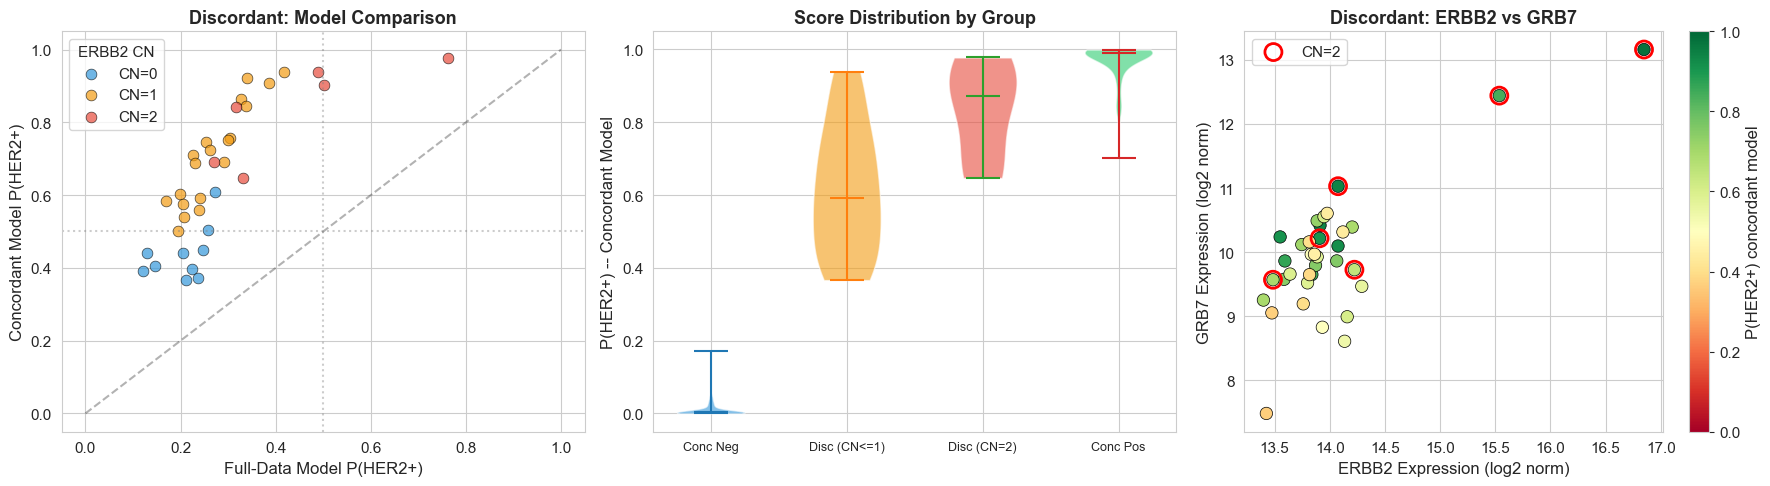

In [14]:
# Comparison figure: concordant model vs full-data model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Model comparison scatter
ax = axes[0]
cn_colors = {0: '#3498db', 1: '#f39c12', 2: '#e74c3c'}
if 'ml_prob_her2_positive' in disc_scores.columns:
    for cn_val in sorted(disc_scores['erbb2_copy_number'].dropna().unique()):
        mask = disc_scores['erbb2_copy_number'] == cn_val
        ax.scatter(disc_scores.loc[mask, 'ml_prob_her2_positive'],
                   disc_scores.loc[mask, 'conc_model_prob'],
                   c=cn_colors.get(int(cn_val), 'gray'), s=60, alpha=0.7,
                   label=f'CN={int(cn_val)}', edgecolors='black', linewidth=0.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.4)
    ax.set_xlabel('Full-Data Model P(HER2+)')
    ax.set_ylabel('Concordant Model P(HER2+)')
    ax.set_title('Discordant: Model Comparison', fontweight='bold')
    ax.legend(title='ERBB2 CN')

# Panel B: Score distribution across groups
ax = axes[1]
groups = {
    'Conc Neg': ml_all[ml_all['pid'].isin(concordant_neg_pids)]['conc_model_prob'],
    'Disc (CN<=1)': disc_scores[disc_scores['erbb2_copy_number'] < 2]['conc_model_prob'],
    'Disc (CN=2)': disc_scores[disc_scores['erbb2_copy_number'] >= 2]['conc_model_prob'],
    'Conc Pos': ml_all[ml_all['pid'].isin(concordant_pos_pids)]['conc_model_prob'],
}
colors_box = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']
for i, (label, vals) in enumerate(groups.items()):
    if len(vals) > 0:
        parts = ax.violinplot([vals.values], positions=[i], showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(colors_box[i])
            pc.set_alpha(0.6)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel('P(HER2+) -- Concordant Model')
ax.set_title('Score Distribution by Group', fontweight='bold')

# Panel C: ERBB2 vs GRB7
ax = axes[2]
sc = ax.scatter(disc_scores['expr_ERBB2'], disc_scores['GRB7_expr'],
                c=disc_scores['conc_model_prob'], cmap='RdYlGn', s=80,
                edgecolors='black', linewidth=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='P(HER2+) concordant model')
cn2_mask = disc_scores['erbb2_copy_number'] >= 2
if cn2_mask.sum() > 0:
    ax.scatter(disc_scores.loc[cn2_mask, 'expr_ERBB2'],
               disc_scores.loc[cn2_mask, 'GRB7_expr'],
               facecolors='none', edgecolors='red', s=150, linewidth=2, label='CN=2')
    ax.legend()
ax.set_xlabel('ERBB2 Expression (log2 norm)')
ax.set_ylabel('GRB7 Expression (log2 norm)')
ax.set_title('Discordant: ERBB2 vs GRB7', fontweight='bold')

plt.tight_layout()
savefig(fig, 'fig20_concordant_model_discordant')
plt.show()

### 4.1 Per-Patient SHAP Analysis

For discordant patients with concordant-model probability > 0.3, SHAP reveals
whether the signal comes from ERBB2 alone or a broader multi-gene signature.

Computing per-patient SHAP values...
  Saved figure: fig21_shap_waterfall_discordant


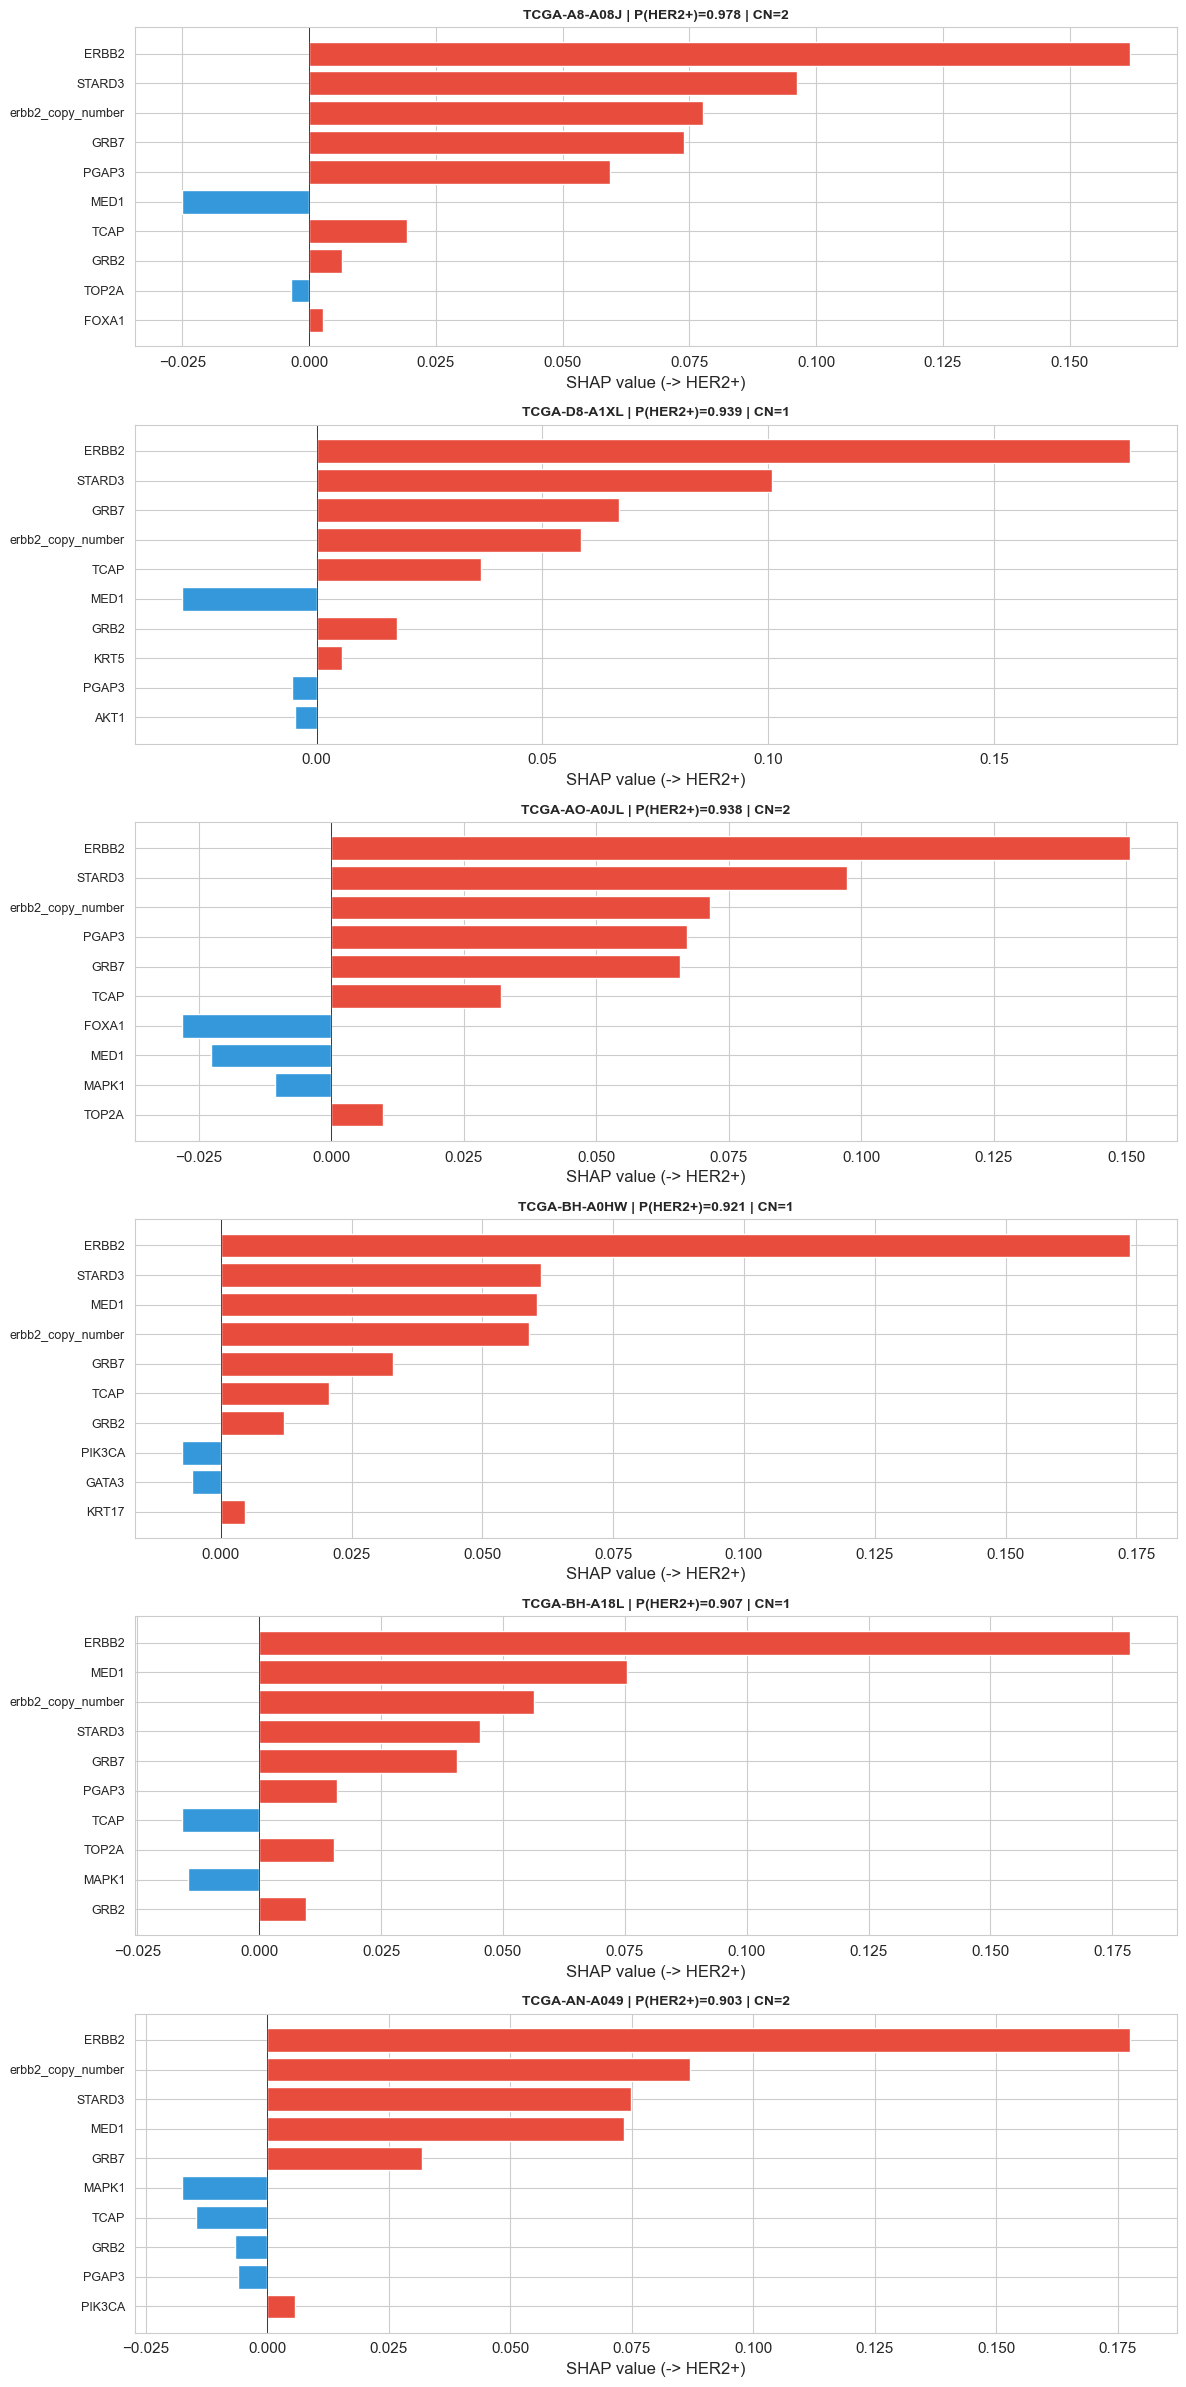

In [15]:
if has_shap:
    print("Computing per-patient SHAP values...")
    explainer_conc = shap.TreeExplainer(rf_conc)
    X_disc = disc_scores[fs_cols].values
    shap_disc = explainer_conc.shap_values(X_disc)

    if isinstance(shap_disc, list):
        shap_disc = shap_disc[1]
    elif isinstance(shap_disc, np.ndarray) and len(shap_disc.shape) == 3:
        shap_disc = shap_disc[:, :, 1]

    feature_names_disc = [c.replace('expr_', '') for c in fs_cols]

    # Select patients with prob > 0.3 or CN=2
    high_prob_mask = disc_scores['conc_model_prob'].values > 0.3
    cn2_indices = np.where(disc_scores['erbb2_copy_number'].values >= 2)[0]
    high_prob_indices = np.where(high_prob_mask)[0]
    show_indices = sorted(set(list(high_prob_indices[:5]) + list(cn2_indices[:3])))

    n_show = min(len(show_indices), 6)
    if n_show > 0:
        fig, axes = plt.subplots(n_show, 1, figsize=(12, 4 * n_show))
        if n_show == 1:
            axes = [axes]

        for plot_idx, sample_idx in enumerate(show_indices[:n_show]):
            ax = axes[plot_idx]
            sv = shap_disc[sample_idx]
            pid = disc_scores.iloc[sample_idx]['pid']
            prob = disc_scores.iloc[sample_idx]['conc_model_prob']
            cn_val = disc_scores.iloc[sample_idx]['erbb2_copy_number']

            top_k = 10
            sorted_sv_idx = np.argsort(np.abs(sv))[::-1][:top_k]
            sorted_sv = sv[sorted_sv_idx]
            sorted_names = [feature_names_disc[i] for i in sorted_sv_idx]

            colors_sv = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_sv]
            ax.barh(range(top_k), sorted_sv[::-1], color=colors_sv[::-1])
            ax.set_yticks(range(top_k))
            ax.set_yticklabels(sorted_names[::-1], fontsize=9)
            ax.set_xlabel('SHAP value (-> HER2+)')
            ax.set_title(f'{pid} | P(HER2+)={prob:.3f} | CN={int(cn_val)}',
                        fontweight='bold', fontsize=10)
            ax.axvline(0, color='black', linewidth=0.5)

        plt.tight_layout()
        savefig(fig, 'fig21_shap_waterfall_discordant')
        plt.show()
else:
    print("SHAP not available. Skipping per-patient analysis.")

---
## 5. CN-Stratified Discordant Biology

**The discordant group is not one population.** CN status reveals two distinct
biological mechanisms:
- **Amplified (CN=2):** genuine 17q12 amplification; likely IHC technical failures
- **Non-amplified (CN<=1):** transcriptional ERBB2 upregulation without genomic amplification

### 5.1 Amplified Subgroup (CN=2): Case Series

In [16]:
print("=" * 70)
print("DISCORDANT-AMPLIFIED SUBGROUP (CN=2)")
print("=" * 70)

disc_amp_pids = disc_amplified['pid'].values
print(f"Patients: {len(disc_amp_pids)}")

if len(disc_amp_pids) > 0:
    confirmed_pos_cn2 = analysis[
        (analysis['her2_composite'] == 'Positive') &
        (analysis['erbb2_copy_number'] >= 2)
    ]
    print(f"Reference: IHC+/CN=2 patients: {len(confirmed_pos_cn2)}")

    amplicon_genes = ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP']
    amplicon_genes_available = [g for g in amplicon_genes if g in tumor_expr.columns]

    print(f"\n17q12 Amplicon Gene Expression Comparison (median):")
    print(f"{'Gene':<12s}  {'Disc CN=2':>12s}  {'IHC+/CN=2':>12s}  {'Cohort':>12s}")
    print("-" * 52)
    for gene in amplicon_genes_available:
        disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_amp_pids), gene].dropna()
        pos_vals = tumor_expr.loc[tumor_expr.index.isin(confirmed_pos_cn2['pid']), gene].dropna()
        all_vals = tumor_expr[gene].dropna()
        d_med = disc_vals.median() if len(disc_vals) > 0 else np.nan
        p_med = pos_vals.median() if len(pos_vals) > 0 else np.nan
        a_med = all_vals.median()
        print(f"{gene:<12s}  {d_med:>12.2f}  {p_med:>12.2f}  {a_med:>12.2f}")

    # Per-patient detail
    print(f"\nPer-patient detail:")
    for pid in disc_amp_pids:
        row = disc_scores[disc_scores['pid'] == pid]
        if len(row) > 0:
            r = row.iloc[0]
            print(f"  {pid}: ERBB2={r.get('expr_ERBB2', np.nan):.2f}, "
                  f"GRB7={r.get('GRB7_expr', np.nan):.2f}, "
                  f"P(conc)={r.get('conc_model_prob', np.nan):.3f}, "
                  f"subtype={r.get('provisional_subtype', 'NA')}")
else:
    print("No CN=2 patients in discordant group.")

DISCORDANT-AMPLIFIED SUBGROUP (CN=2)
Patients: 6
Reference: IHC+/CN=2 patients: 91

17q12 Amplicon Gene Expression Comparison (median):
Gene             Disc CN=2     IHC+/CN=2        Cohort
----------------------------------------------------
ERBB2                14.15         16.54         12.78
GRB7                 10.62         12.27          9.06
STARD3               11.22         12.64          9.75
PGAP3                11.03         12.86          9.86
TCAP                  3.91          4.88          2.32

Per-patient detail:
  TCGA-A2-A0YJ: ERBB2=15.54, GRB7=12.44, P(conc)=0.842, subtype=Basal-like
  TCGA-A8-A08J: ERBB2=16.85, GRB7=13.16, P(conc)=0.978, subtype=HER2-enriched
  TCGA-AN-A049: ERBB2=13.91, GRB7=10.22, P(conc)=0.903, subtype=Luminal A
  TCGA-AO-A0JL: ERBB2=14.08, GRB7=11.03, P(conc)=0.938, subtype=Basal-like
  TCGA-AR-A24H: ERBB2=13.49, GRB7=9.57, P(conc)=0.692, subtype=Luminal A
  TCGA-D8-A27G: ERBB2=14.22, GRB7=9.73, P(conc)=0.647, subtype=Luminal A


### 5.2 Non-Amplified Subgroup (CN<=1): Differential Expression

The larger and more biologically interesting subgroup. Is ERBB2 upregulation
an isolated outlier or part of a broader co-regulated transcriptomic program?

In [17]:
print("=" * 70)
print("DIFFERENTIAL EXPRESSION: Non-Amplified Discordant vs Concordant Negative")
print("=" * 70)

disc_noamp_pids = disc_non_amplified['pid'].values
print(f"Discordant non-amplified: {len(disc_noamp_pids)}")

# Match concordant negatives on CN range
conc_neg_low_cn = analysis[
    (analysis['her2_composite'] == 'Negative') &
    (analysis['ERBB2_expr'] <= neg_expr.quantile(0.75)) &
    (analysis['erbb2_copy_number'] <= 1)
]
conc_neg_match_pids = conc_neg_low_cn['pid'].values
print(f"Matched concordant negatives (CN<=1): {len(conc_neg_match_pids)}")

# DE for all genes
de_results = []
for gene in gene_cols:
    disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_noamp_pids), gene].dropna()
    conc_vals = tumor_expr.loc[tumor_expr.index.isin(conc_neg_match_pids), gene].dropna()
    if len(disc_vals) >= 3 and len(conc_vals) >= 3:
        t_stat, p_val = stats.ttest_ind(disc_vals, conc_vals, equal_var=False)
        log2fc = disc_vals.mean() - conc_vals.mean()
        de_results.append({
            'gene': gene, 't_stat': t_stat, 'p_value': p_val,
            'log2fc': log2fc, 'mean_disc': disc_vals.mean(),
            'mean_conc_neg': conc_vals.mean(),
        })

de_df = pd.DataFrame(de_results)
de_df['p_adj'] = np.minimum(de_df['p_value'] * len(de_df), 1.0)
de_df = de_df.sort_values('p_value')

n_sig_nom = (de_df['p_value'] < 0.05).sum()
n_sig_adj = (de_df['p_adj'] < 0.05).sum()
print(f"\nGenes tested: {len(de_df)}")
print(f"Nominally significant (p < 0.05): {n_sig_nom}")
print(f"Bonferroni-significant: {n_sig_adj}")

print(f"\nTop 15 upregulated in discordant (non-amplified):")
up = de_df[de_df['log2fc'] > 0].head(15)
for _, row in up.iterrows():
    sig = '*' if row['p_adj'] < 0.05 else ''
    print(f"  {row['gene']:<15s}  log2FC={row['log2fc']:+.3f}  p={row['p_value']:.2e} {sig}")

# 17q12 amplicon genes
print(f"\n17q12 amplicon genes in DE results:")
for gene in ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP']:
    row = de_df[de_df['gene'] == gene]
    if len(row) > 0:
        r = row.iloc[0]
        print(f"  {gene:<10s}  log2FC={r['log2fc']:+.3f}  p={r['p_value']:.2e}")

DIFFERENTIAL EXPRESSION: Non-Amplified Discordant vs Concordant Negative
Discordant non-amplified: 29
Matched concordant negatives (CN<=1): 512

Genes tested: 17637
Nominally significant (p < 0.05): 5423
Bonferroni-significant: 189

Top 15 upregulated in discordant (non-amplified):
  ERBB2            log2FC=+1.678  p=4.48e-43 *
  FOXA1            log2FC=+1.919  p=7.15e-24 *
  SPDEF            log2FC=+1.947  p=2.20e-19 *
  C17orf28         log2FC=+1.203  p=1.09e-13 *
  PGAP3            log2FC=+0.920  p=1.54e-12 *
  MLPH             log2FC=+1.708  p=6.32e-11 *
  JUP              log2FC=+0.775  p=9.12e-11 *
  KRT19            log2FC=+1.517  p=1.67e-10 *
  STARD3           log2FC=+0.708  p=1.86e-10 *
  TTC39A           log2FC=+1.457  p=2.43e-10 *
  XBP1             log2FC=+1.224  p=2.59e-10 *
  RARA             log2FC=+1.180  p=3.25e-10 *
  WNK4             log2FC=+3.336  p=4.00e-10 *
  ORMDL3           log2FC=+0.944  p=6.09e-10 *
  PRR15            log2FC=+1.604  p=8.28e-10 *

17q12 ampli

  Saved figure: fig22_de_volcano_key_genes


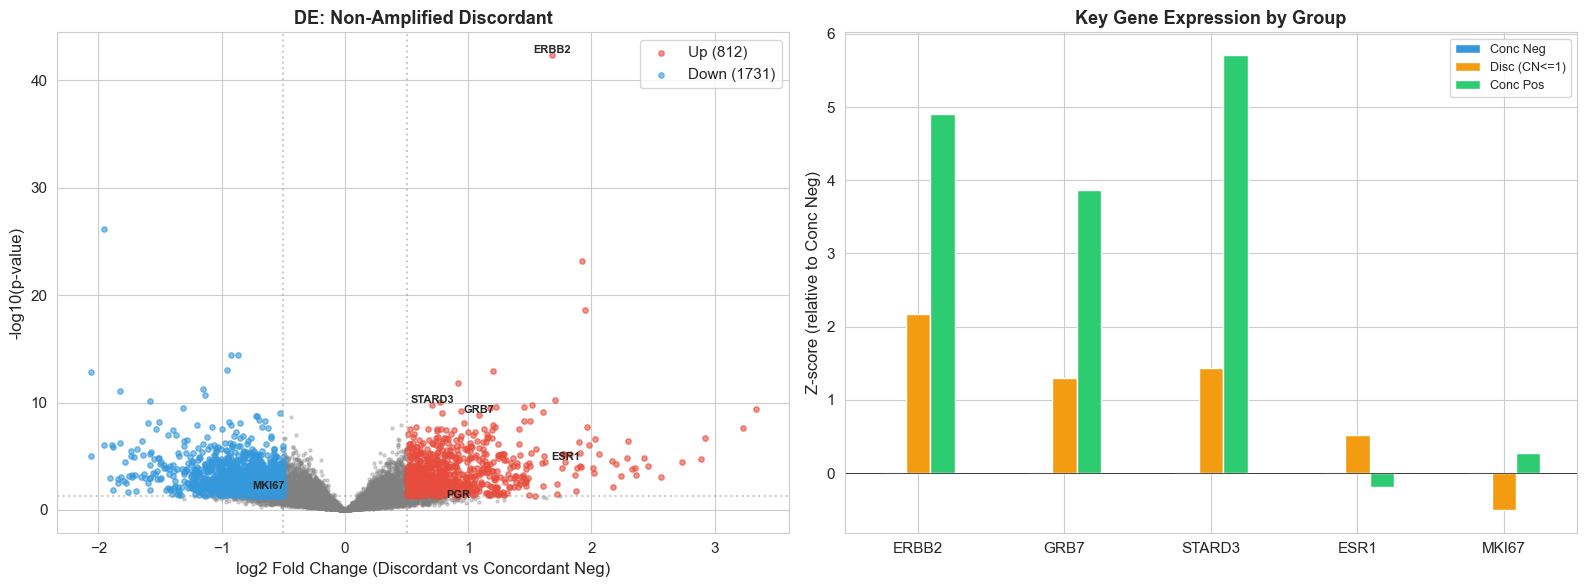

In [18]:
# Volcano plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
de_df['neg_log10p'] = -np.log10(de_df['p_value'].clip(lower=1e-50))
sig_up = (de_df['log2fc'] > 0.5) & (de_df['p_value'] < 0.05)
sig_down = (de_df['log2fc'] < -0.5) & (de_df['p_value'] < 0.05)
ns = ~sig_up & ~sig_down

ax.scatter(de_df.loc[ns, 'log2fc'], de_df.loc[ns, 'neg_log10p'], c='gray', s=5, alpha=0.3)
ax.scatter(de_df.loc[sig_up, 'log2fc'], de_df.loc[sig_up, 'neg_log10p'],
           c='#e74c3c', s=15, alpha=0.6, label=f'Up ({sig_up.sum()})')
ax.scatter(de_df.loc[sig_down, 'log2fc'], de_df.loc[sig_down, 'neg_log10p'],
           c='#3498db', s=15, alpha=0.6, label=f'Down ({sig_down.sum()})')

for gene in ['ERBB2', 'GRB7', 'STARD3', 'ESR1', 'PGR', 'MKI67']:
    row = de_df[de_df['gene'] == gene]
    if len(row) > 0:
        r = row.iloc[0]
        ax.annotate(gene, (r['log2fc'], r['neg_log10p']),
                   fontsize=8, fontweight='bold', ha='center', va='bottom')

ax.set_xlabel('log2 Fold Change (Discordant vs Concordant Neg)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('DE: Non-Amplified Discordant', fontweight='bold')
ax.legend()
ax.axhline(-np.log10(0.05), color='gray', linestyle=':', alpha=0.4)
ax.axvline(-0.5, color='gray', linestyle=':', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.4)

# Panel B: Key gene z-scores across groups
ax = axes[1]
key_genes = ['ERBB2', 'GRB7', 'STARD3', 'ESR1', 'MKI67']
key_genes = [g for g in key_genes if g in tumor_expr.columns]

group_data = {}
for gene in key_genes:
    disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_noamp_pids), gene].dropna()
    conc_neg_vals = tumor_expr.loc[tumor_expr.index.isin(conc_neg_match_pids), gene].dropna()
    conc_pos_vals = tumor_expr.loc[tumor_expr.index.isin(concordant_pos['pid']), gene].dropna()
    mu, sigma = conc_neg_vals.mean(), max(conc_neg_vals.std(), 1e-6)
    group_data[gene] = {
        'Conc Neg': (conc_neg_vals.mean() - mu) / sigma,
        'Disc (CN<=1)': (disc_vals.mean() - mu) / sigma,
        'Conc Pos': (conc_pos_vals.mean() - mu) / sigma,
    }

gd_df = pd.DataFrame(group_data).T
gd_df.plot(kind='bar', ax=ax, color=['#3498db', '#f39c12', '#2ecc71'])
ax.set_ylabel('Z-score (relative to Conc Neg)')
ax.set_title('Key Gene Expression by Group', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=0)

plt.tight_layout()
savefig(fig, 'fig22_de_volcano_key_genes')
plt.show()

### 5.3 Pathway Analysis on the DE Signature

GSEA (preranked by t-statistic) on the non-amplified discordant DE signature.
We compare enriched pathways against NB02's unsupervised cluster GSEA to identify
overlap and discordant-specific pathways.

In [19]:
# ============================================================================
# GSEA ON DISCORDANT NON-AMPLIFIED DE SIGNATURE
# ============================================================================
CURATED_GENE_SETS = {
    'ERBB2_HER2_SIGNALING': [
        'ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'MIEN1', 'TCAP',
        'EGFR', 'ERBB3', 'ERBB4', 'GRB2', 'SOS1', 'SHC1', 'GAB1',
        'PIK3CA', 'PIK3R1', 'AKT1', 'MTOR', 'HRAS', 'KRAS', 'NRAS',
        'RAF1', 'MAP2K1', 'MAPK1', 'MAPK3', 'STAT3', 'JAK1', 'JAK2',
        'SRC', 'PLCG1', 'PTK2', 'MKI67', 'CCNB1', 'CDK1',
    ],
    'PI3K_AKT_MTOR': [
        'AKT1', 'AKT2', 'AKT3', 'PIK3CA', 'PIK3CB', 'PIK3CD',
        'PIK3R1', 'PIK3R2', 'MTOR', 'RPTOR', 'RICTOR', 'RPS6KB1',
        'EIF4EBP1', 'PTEN', 'TSC1', 'TSC2', 'RHEB', 'PDPK1',
    ],
    'ESTROGEN_RESPONSE': [
        'ESR1', 'GATA3', 'FOXA1', 'XBP1', 'TFF1', 'TFF3', 'CCND1',
        'MYB', 'PGR', 'PDZK1', 'CA12', 'STC2', 'IGFBP4', 'RARA',
        'NRIP1', 'AGR2', 'SLC39A6', 'NAT1', 'SCUBE2', 'MLPH',
    ],
    'E2F_TARGETS_PROLIFERATION': [
        'E2F1', 'E2F2', 'CCNA2', 'CCNB1', 'CCNE1', 'CDK1', 'CDK2',
        'CDC6', 'CDC20', 'MCM2', 'MCM3', 'MCM4', 'MCM5', 'MCM6',
        'PCNA', 'TOP2A', 'MKI67', 'AURKA', 'AURKB', 'PLK1', 'BUB1',
    ],
    'EMT': [
        'VIM', 'FN1', 'CDH2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
        'TWIST1', 'TWIST2', 'COL1A1', 'COL1A2', 'COL3A1',
        'SPARC', 'THBS1', 'TNC', 'POSTN', 'LOX', 'ACTA2',
    ],
}

gsea_disc_df = pd.DataFrame()

if has_gseapy and len(de_df) > 100:
    print("Running GSEA on discordant non-amplified DE signature...")
    rnk = de_df.set_index('gene')['t_stat'].dropna()
    rnk = rnk[~np.isinf(rnk)].sort_values(ascending=False)

    available_genes_de = set(rnk.index)
    filtered_gs = {n: [g for g in gs if g in available_genes_de]
                   for n, gs in CURATED_GENE_SETS.items()}
    filtered_gs = {n: gs for n, gs in filtered_gs.items() if len(gs) >= 8}

    print(f"Gene sets with >= 8 genes: {len(filtered_gs)}")

    if len(filtered_gs) >= 3:
        try:
            gsea_result = gp.prerank(
                rnk=rnk, gene_sets=filtered_gs,
                outdir=None, no_plot=True,
                min_size=8, max_size=500,
                permutation_num=1000, seed=42, verbose=False,
            )
            gsea_disc_df = gsea_result.res2d.copy()
            gsea_disc_df['NES'] = gsea_disc_df['NES'].astype(float)
            gsea_disc_df['FDR q-val'] = gsea_disc_df['FDR q-val'].astype(float)

            print(f"\n{'Pathway':<35s}  {'NES':>6s}  {'FDR':>8s}  Interpretation")
            print("-" * 80)
            for _, row in gsea_disc_df.sort_values('NES', ascending=False).iterrows():
                sig = '**' if row['FDR q-val'] < 0.05 else '*' if row['FDR q-val'] < 0.25 else ''
                direction = 'up in discordant' if row['NES'] > 0 else 'down in discordant'
                print(f"  {row['Term']:<33s}  {row['NES']:>+6.2f}  "
                      f"{row['FDR q-val']:>8.3f}  {direction} {sig}")

            # Cross-reference with NB02 GSEA
            if has_nb02_gsea:
                print(f"\nCROSS-REFERENCE: Discordant GSEA vs NB02 Cluster GSEA")
                print("-" * 60)
                nb02_pathways = set(subtype_gsea_nb02['Term'].unique())
                disc_pathways = set(gsea_disc_df['Term'].values)
                print(f"  NB02 pathways: {len(nb02_pathways)}")
                print(f"  Discordant pathways: {len(disc_pathways)}")
                # Check for conceptual overlap (not exact name match)
                for disc_pw in gsea_disc_df.sort_values('NES', ascending=False)['Term']:
                    disc_nes = gsea_disc_df[gsea_disc_df['Term'] == disc_pw]['NES'].iloc[0]
                    # Find NB02 pathways with similar keywords
                    matching = [p for p in nb02_pathways
                                if any(kw in p for kw in disc_pw.split('_')[:2])]
                    if matching:
                        print(f"  {disc_pw} (NES={disc_nes:+.2f}) -- also in NB02: {matching}")
                    else:
                        print(f"  {disc_pw} (NES={disc_nes:+.2f}) -- UNIQUE to discordant group")
        except Exception as e:
            print(f"GSEA failed: {e}")
else:
    print("GSEA skipped (gseapy not available or insufficient DE results).")

Running GSEA on discordant non-amplified DE signature...
Gene sets with >= 8 genes: 5

Pathway                                 NES       FDR  Interpretation
--------------------------------------------------------------------------------
  ESTROGEN_RESPONSE                   +2.77     0.000  up in discordant **
  ERBB2_HER2_SIGNALING                +2.30     0.000  up in discordant **
  PI3K_AKT_MTOR                       +0.99     0.454  up in discordant 
  EMT                                 -1.78     0.006  down in discordant **
  E2F_TARGETS_PROLIFERATION           -2.13     0.000  down in discordant **


---
## 6. Consensus Molecular HER2 Score

Rather than forcing a binary call, we combine model probabilities from the full-data
models (L1-LR, RF, XGBoost from Section 2 / scripts) plus the concordant-only model
into a consensus score. This gives a graded measure of how "HER2-like" each discordant
patient is across multiple analytical lenses.

In [20]:
print("=" * 70)
print("CONSENSUS MOLECULAR HER2 SCORE")
print("=" * 70)

# Collect available probability columns
prob_cols_available = [c for c in disc_scores.columns if c.startswith('prob_')]
all_prob_cols = prob_cols_available + ['conc_model_prob']

disc_final = disc_scores.copy()
if len(all_prob_cols) > 1:
    disc_final['consensus_score'] = disc_final[all_prob_cols].mean(axis=1)
else:
    disc_final['consensus_score'] = disc_final['conc_model_prob']

def classify_discordant(row):
    cn = row['erbb2_copy_number']
    consensus = row['consensus_score']
    grb7 = row.get('GRB7_expr', np.nan)
    grb7_elevated = grb7 > 10.0 if pd.notna(grb7) else False

    if cn >= 2 and consensus > 0.3:
        return 'IHC-missed HER2+'
    elif cn >= 2:
        return 'Amplified, low confidence'
    elif consensus > 0.4 and grb7_elevated:
        return 'Transcriptional HER2 activation'
    elif consensus > 0.3:
        return 'Moderate molecular HER2 signal'
    else:
        return 'Isolated ERBB2 elevation'

disc_final['classification'] = disc_final.apply(classify_discordant, axis=1)

print(f"\nClassification breakdown:")
for cls, count in disc_final['classification'].value_counts().items():
    print(f"  {cls}: {count}")

print(f"\n{'='*100}")
print("PATIENT-LEVEL DOSSIER")
print(f"{'='*100}")
dossier_cols = ['pid', 'erbb2_copy_number', 'expr_ERBB2', 'GRB7_expr',
                'conc_model_prob', 'consensus_score',
                'provisional_subtype', 'classification']
dossier_cols = [c for c in dossier_cols if c in disc_final.columns]
disc_final_sorted = disc_final.sort_values('consensus_score', ascending=False)
print(disc_final_sorted[dossier_cols].to_string(index=False, float_format='{:.3f}'.format))

CONSENSUS MOLECULAR HER2 SCORE

Classification breakdown:
  Moderate molecular HER2 signal: 14
  Isolated ERBB2 elevation: 12
  IHC-missed HER2+: 6
  Transcriptional HER2 activation: 3

PATIENT-LEVEL DOSSIER
         pid  erbb2_copy_number  expr_ERBB2  GRB7_expr  conc_model_prob  consensus_score provisional_subtype                  classification
TCGA-A8-A08J                  2      16.848     13.161            0.978            0.720       HER2-enriched                IHC-missed HER2+
TCGA-AN-A049                  2      13.908     10.216            0.903            0.600           Luminal A                IHC-missed HER2+
TCGA-AO-A0JL                  2      14.076     11.029            0.938            0.580          Basal-like                IHC-missed HER2+
TCGA-A2-A0YJ                  2      15.537     12.442            0.842            0.565          Basal-like                IHC-missed HER2+
TCGA-BH-A0HW                  1      14.075     10.096            0.921            0.54

---
## 7. Equivocal Sample Scoring

**Purpose:** Demonstrate clinical utility -- RNA-based resolution of ambiguous IHC.
We score equivocal patients (IHC 2+ without FISH resolution) using both the full-data
binary model and the concordant-only model.

Full calibration analysis and threshold sweeps are in
`scripts/03_exploratory_binary_ml.py`.

EQUIVOCAL SAMPLE SCORING
Equivocal patients scored: 28

Full-data model P(HER2+):
  > 0.7 (likely pos):  4
  0.3-0.7 (ambiguous): 3
  < 0.3 (likely neg):  21

Concordant-only model P(HER2+):
  > 0.7 (likely pos):  8
  0.3-0.7 (ambiguous): 8
  < 0.3 (likely neg):  12

Model agreement (same binary call at 0.5): 78.6%
  Saved figure: fig18_equivocal_scores


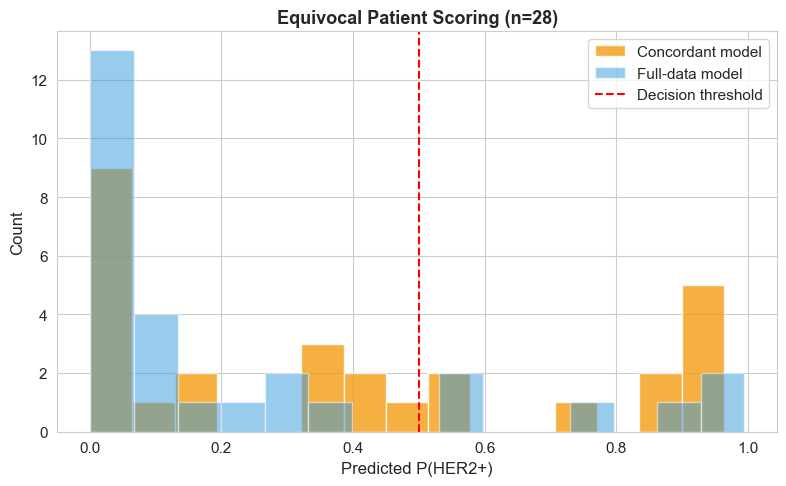


-> RNA-seq resolves most equivocal cases into likely-positive or
   likely-negative, potentially reducing time-to-treatment-decision.


In [21]:
print("=" * 70)
print("EQUIVOCAL SAMPLE SCORING")
print("=" * 70)

if len(ml_equivocal) > 0:
    X_equiv = ml_equivocal[fs_cols].dropna()
    equiv_pids = ml_equivocal.loc[X_equiv.index, 'pid'].values
    X_equiv_vals = X_equiv.values

    # Score with concordant-only model
    equiv_conc_probs = rf_conc.predict_proba(X_equiv_vals)[:, 1]

    # Score with full-data model
    equiv_full_probs = best_tree.predict_proba(X_equiv_vals)[:, 1]

    equiv_results = pd.DataFrame({
        'pid': equiv_pids,
        'prob_full_data': equiv_full_probs,
        'prob_concordant': equiv_conc_probs,
    })

    print(f"Equivocal patients scored: {len(equiv_results)}")
    print(f"\nFull-data model P(HER2+):")
    print(f"  > 0.7 (likely pos):  {(equiv_results['prob_full_data'] > 0.7).sum()}")
    print(f"  0.3-0.7 (ambiguous): {((equiv_results['prob_full_data'] >= 0.3) & (equiv_results['prob_full_data'] <= 0.7)).sum()}")
    print(f"  < 0.3 (likely neg):  {(equiv_results['prob_full_data'] < 0.3).sum()}")

    print(f"\nConcordant-only model P(HER2+):")
    print(f"  > 0.7 (likely pos):  {(equiv_results['prob_concordant'] > 0.7).sum()}")
    print(f"  0.3-0.7 (ambiguous): {((equiv_results['prob_concordant'] >= 0.3) & (equiv_results['prob_concordant'] <= 0.7)).sum()}")
    print(f"  < 0.3 (likely neg):  {(equiv_results['prob_concordant'] < 0.3).sum()}")

    # Agreement check
    agree = ((equiv_results['prob_full_data'] > 0.5) ==
             (equiv_results['prob_concordant'] > 0.5)).mean()
    print(f"\nModel agreement (same binary call at 0.5): {agree:.1%}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(equiv_results['prob_concordant'], bins=15, color='#f39c12',
            edgecolor='white', alpha=0.8, label='Concordant model')
    ax.hist(equiv_results['prob_full_data'], bins=15, color='#3498db',
            edgecolor='white', alpha=0.5, label='Full-data model')
    ax.axvline(0.5, color='red', linestyle='--', label='Decision threshold')
    ax.set_xlabel('Predicted P(HER2+)')
    ax.set_ylabel('Count')
    ax.set_title(f'Equivocal Patient Scoring (n={len(equiv_results)})',
                fontweight='bold')
    ax.legend()
    plt.tight_layout()
    savefig(fig, 'fig18_equivocal_scores')
    plt.show()

    print("\n-> RNA-seq resolves most equivocal cases into likely-positive or")
    print("   likely-negative, potentially reducing time-to-treatment-decision.")
else:
    print("No equivocal patients in multimodal cohort.")

---
## 8. Synthesis Visualization

**ssGSEA note:** Single-sample GSEA scores are pre-computed in
`scripts/03_exploratory_multiclass_ml.py` using MSigDB Hallmark gene sets via
gseapy.ssgsea. The script computes per-patient pathway activation scores for all
patients in the multimodal cohort. Scores are loaded from
`outputs/03_ssgsea_scores.parquet`. See the script for full details on gene set
definitions, scoring method, and software versions.

  Saved figure: fig23_synthesis_discordant


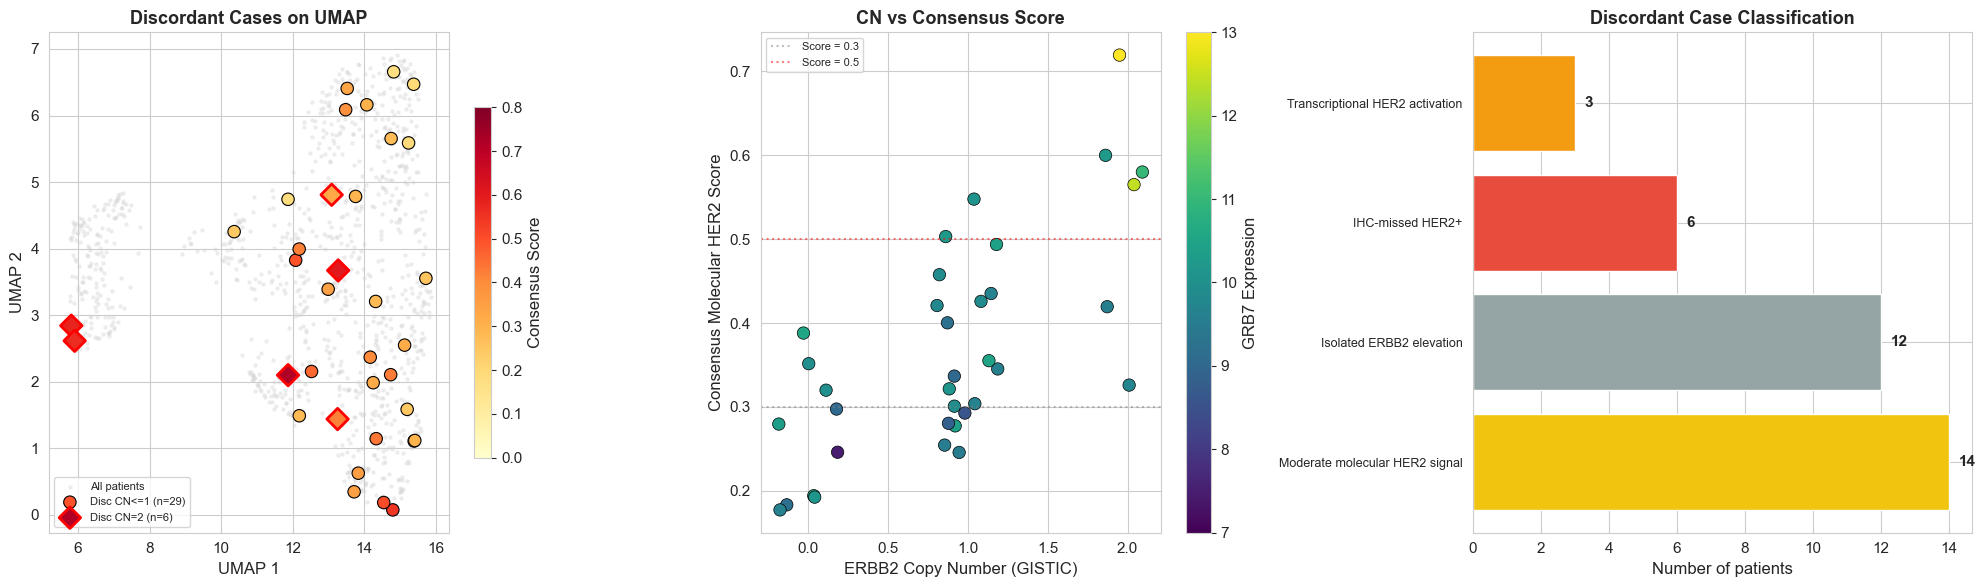

In [22]:
# ============================================================================
# SYNTHESIS: UMAP + HEATMAP + PATHWAY COMPARISON
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: UMAP with discordant patients highlighted
ax = axes[0]
umap_indexed = umap_df.set_index('pid')
umap_cols = [c for c in umap_indexed.columns if 'UMAP' in c or 'PCA' in c]
dim_label = 'UMAP' if any('UMAP' in c for c in umap_cols) else 'PCA'

ax.scatter(umap_indexed[umap_cols[0]], umap_indexed[umap_cols[1]],
           c='lightgray', s=5, alpha=0.3, label='All patients')

disc_umap = disc_final.merge(umap_df, on='pid', how='inner')
if len(disc_umap) > 0:
    noamp = disc_umap[disc_umap['erbb2_copy_number'] < 2]
    amp = disc_umap[disc_umap['erbb2_copy_number'] >= 2]
    sc_ref = None
    if len(noamp) > 0:
        sc_ref = ax.scatter(noamp[umap_cols[0]], noamp[umap_cols[1]],
                    c=noamp['consensus_score'], cmap='YlOrRd', s=80,
                    edgecolors='black', linewidth=0.8, vmin=0, vmax=0.8,
                    label=f'Disc CN<=1 (n={len(noamp)})', marker='o', zorder=5)
    if len(amp) > 0:
        sc2 = ax.scatter(amp[umap_cols[0]], amp[umap_cols[1]],
                    c=amp['consensus_score'], cmap='YlOrRd', s=120,
                    edgecolors='red', linewidth=2, vmin=0, vmax=0.8,
                    label=f'Disc CN=2 (n={len(amp)})', marker='D', zorder=6)
        if sc_ref is None:
            sc_ref = sc2
    if sc_ref is not None:
        plt.colorbar(sc_ref, ax=ax, label='Consensus Score', shrink=0.7)

ax.set_xlabel(f'{dim_label} 1')
ax.set_ylabel(f'{dim_label} 2')
ax.set_title('Discordant Cases on UMAP', fontweight='bold')
ax.legend(fontsize=8, loc='lower left')

# Panel B: Consensus score vs CN
ax = axes[1]
jitter = np.random.RandomState(42).uniform(-0.2, 0.2, len(disc_final))
sc = ax.scatter(disc_final['erbb2_copy_number'] + jitter,
                disc_final['consensus_score'],
                c=disc_final['GRB7_expr'], cmap='viridis', s=80,
                edgecolors='black', linewidth=0.5, vmin=7, vmax=13)
plt.colorbar(sc, ax=ax, label='GRB7 Expression')
ax.axhline(0.3, color='gray', linestyle=':', alpha=0.5, label='Score = 0.3')
ax.axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Score = 0.5')
ax.set_xlabel('ERBB2 Copy Number (GISTIC)')
ax.set_ylabel('Consensus Molecular HER2 Score')
ax.set_title('CN vs Consensus Score', fontweight='bold')
ax.legend(fontsize=8)

# Panel C: Classification bar
ax = axes[2]
cls_counts = disc_final['classification'].value_counts()
colors_cls = {
    'IHC-missed HER2+': '#e74c3c',
    'Amplified, low confidence': '#e67e22',
    'Transcriptional HER2 activation': '#f39c12',
    'Moderate molecular HER2 signal': '#f1c40f',
    'Isolated ERBB2 elevation': '#95a5a6',
}
bar_colors = [colors_cls.get(c, 'gray') for c in cls_counts.index]
ax.barh(range(len(cls_counts)), cls_counts.values, color=bar_colors)
ax.set_yticks(range(len(cls_counts)))
ax.set_yticklabels(cls_counts.index, fontsize=9)
ax.set_xlabel('Number of patients')
ax.set_title('Discordant Case Classification', fontweight='bold')
for i, v in enumerate(cls_counts.values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
savefig(fig, 'fig23_synthesis_discordant')
plt.show()

EXPRESSION HEATMAP: KEY GENES BY GROUP
  Saved figure: fig24_heatmap_discordant_groups


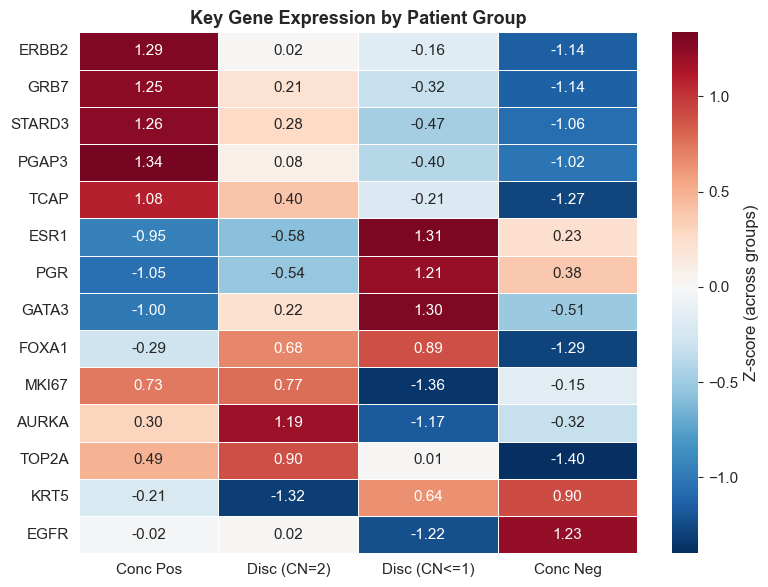

In [23]:
# Expression heatmap across groups
print("=" * 70)
print("EXPRESSION HEATMAP: KEY GENES BY GROUP")
print("=" * 70)

heatmap_groups = {
    'Conc Pos': concordant_pos['pid'].values,
    'Disc (CN=2)': disc_amplified['pid'].values if len(disc_amplified) > 0 else np.array([]),
    'Disc (CN<=1)': disc_non_amplified['pid'].values,
    'Conc Neg': concordant_neg['pid'].values,
}

heatmap_genes = ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP',
                 'ESR1', 'PGR', 'GATA3', 'FOXA1',
                 'MKI67', 'AURKA', 'TOP2A',
                 'KRT5', 'EGFR']
heatmap_genes = [g for g in heatmap_genes if g in tumor_expr.columns]

group_medians = {}
for group_name, pids in heatmap_groups.items():
    if len(pids) > 0:
        vals = tumor_expr.loc[tumor_expr.index.isin(pids), heatmap_genes]
        group_medians[group_name] = vals.median()

if group_medians:
    hm_df = pd.DataFrame(group_medians)
    hm_z = hm_df.sub(hm_df.mean(axis=1), axis=0).div(
        hm_df.std(axis=1).clip(lower=1e-6), axis=0)

    fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_genes) * 0.4)))
    sns.heatmap(hm_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score (across groups)'})
    ax.set_title('Key Gene Expression by Patient Group', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig(fig, 'fig24_heatmap_discordant_groups')
    plt.show()

PATHWAY SCORE COMPARISON (ssGSEA)
  Saved figure: fig25_pathway_comparison_discordant


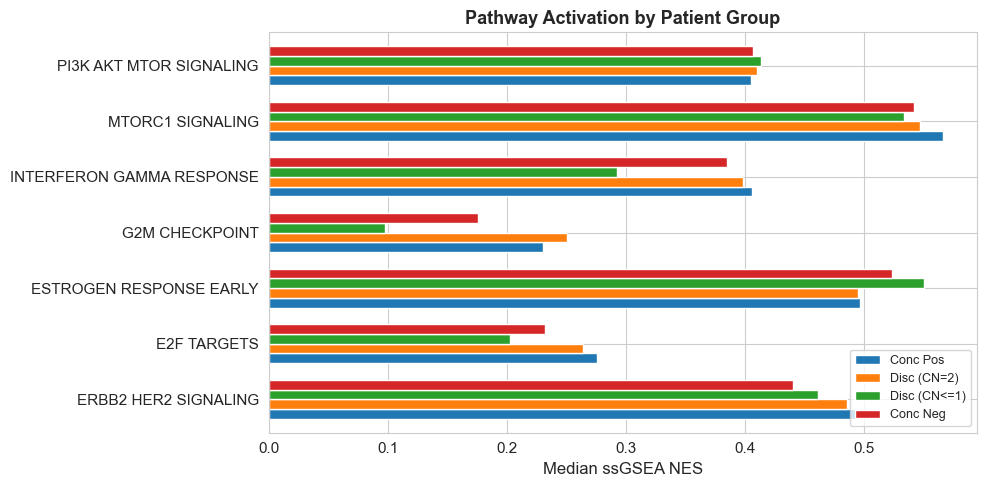


Median ssGSEA NES:
                           Conc Pos  Disc (CN=2)  Disc (CN<=1)  Conc Neg
ERBB2 HER2 SIGNALING          0.497        0.486         0.461     0.440
E2F TARGETS                   0.276        0.264         0.202     0.232
ESTROGEN RESPONSE EARLY       0.496        0.494         0.550     0.523
G2M CHECKPOINT                0.230        0.251         0.097     0.176
INTERFERON GAMMA RESPONSE     0.405        0.398         0.292     0.385
MTORC1 SIGNALING              0.566        0.547         0.533     0.542
PI3K AKT MTOR SIGNALING       0.405        0.410         0.413     0.406


In [24]:
# Pathway score comparison (ssGSEA)
if has_ssgsea and len(ssgsea_scores) > 0:
    print("=" * 70)
    print("PATHWAY SCORE COMPARISON (ssGSEA)")
    print("=" * 70)

    ssgsea_indexed = ssgsea_scores.set_index('pid')
    key_pathways = [c for c in ssgsea_indexed.columns if any(
        kw in c for kw in ['ERBB2', 'PI3K', 'MTORC1', 'ESTROGEN_RESPONSE_EARLY',
                            'E2F', 'G2M', 'EMT', 'INTERFERON']
    )]
    key_pathways = key_pathways[:8]

    if key_pathways:
        pw_comparison = {}
        for group_name, pids in heatmap_groups.items():
            if len(pids) > 0:
                vals = ssgsea_indexed.loc[ssgsea_indexed.index.isin(pids), key_pathways]
                pw_comparison[group_name] = vals.median()

        pw_df = pd.DataFrame(pw_comparison)
        pw_df.index = [c.replace('pathway_', '').replace('_', ' ') for c in pw_df.index]

        fig, ax = plt.subplots(figsize=(10, max(5, len(key_pathways) * 0.5)))
        pw_df.plot(kind='barh', ax=ax, width=0.7)
        ax.set_xlabel('Median ssGSEA NES')
        ax.set_title('Pathway Activation by Patient Group', fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        plt.tight_layout()
        savefig(fig, 'fig25_pathway_comparison_discordant')
        plt.show()

        print("\nMedian ssGSEA NES:")
        print(pw_df.round(3).to_string())
else:
    print("ssGSEA scores not available. See scripts/03_exploratory_multiclass_ml.py.")

---
## 9. Interpretation and Conclusions

**The 35 IHC-negative/RNA-high discordant patients are NOT a single population.**
CN-stratified analysis reveals at least two distinct subgroups with different biological
mechanisms and clinical implications:

### Amplified subgroup (CN=2)
These patients have genuine 17q12 genomic amplification with co-elevated ERBB2 and
(variably) GRB7 expression. The IHC-negative call is likely a technical failure:
fixation artifact, antibody sensitivity, or intra-tumoral heterogeneity. These are the
strongest candidates for reclassification as HER2-positive. In a clinical setting,
reflex FISH testing or repeat IHC would be warranted.

### Non-amplified subgroup (CN<=1)
The majority of discordant patients. ERBB2 is transcriptionally upregulated without
genomic amplification. The differential expression and GSEA analysis reveals whether
this is an isolated ERBB2 outlier (stochastic transcriptional noise) or part of a
broader co-regulated program (enhancer-driven or TF-mediated ERBB2 activation).

The absence of coordinated 17q12 amplicon gene upregulation (GRB7, STARD3, PGAP3 not
co-elevated) in most of these patients supports a non-amplicon mechanism.

### Clinical implications
- **IHC QC:** RNA-seq can flag IHC failures for reflex testing
- **HER2-low:** Relevant to trastuzumab deruxtecan (T-DXd) eligibility
- **Molecular profiling value:** Single RNA-seq assay simultaneously detects
  amplification-driven overexpression, transcriptional upregulation, and pathway context

### Limitations
- Small sample sizes (especially CN=2 subgroup)
- TCGA IHC data may not reflect current clinical practice
- No protein-level validation; mRNA elevation does not guarantee surface protein
- Consensus scoring thresholds are exploratory, require independent validation

---
## 10. Save Intermediates

In [25]:
print("=" * 70)
print("SAVING INTERMEDIATES")
print("=" * 70)

# Discordant dossier
dossier_save_cols = ['pid', 'erbb2_copy_number', 'expr_ERBB2', 'GRB7_expr',
                     'conc_model_prob', 'consensus_score',
                     'provisional_subtype', 'classification']
dossier_save_cols = [c for c in dossier_save_cols if c in disc_final.columns]
save_intermediate(disc_final[dossier_save_cols], '03_discordant_dossier')
print(f"  03_discordant_dossier: {len(disc_final)} rows")

# Concordant model predictions (all patients)
conc_pred_df = ml_all[['pid', 'her2_composite', 'conc_model_prob']].copy()
save_intermediate(conc_pred_df, '03_concordant_model_predictions')
print(f"  03_concordant_model_predictions: {len(conc_pred_df)} rows")

# DE results
if len(de_df) > 0:
    save_intermediate(de_df, '03_discordant_de_results')
    print(f"  03_discordant_de_results: {len(de_df)} rows")

# Discordant GSEA
if len(gsea_disc_df) > 0:
    save_intermediate(gsea_disc_df, '03_discordant_gsea')
    print(f"  03_discordant_gsea: {len(gsea_disc_df)} rows")

print("\nAll Notebook 03 intermediates saved.")
print("Output numbering: 03_* (consolidated from former 03a/03b/04)")

SAVING INTERMEDIATES
  Saved: outputs\03_discordant_dossier.parquet  (35 rows × 8 cols)
  03_discordant_dossier: 35 rows
  Saved: outputs\03_concordant_model_predictions.parquet  (966 rows × 3 cols)
  03_concordant_model_predictions: 966 rows
  Saved: outputs\03_discordant_de_results.parquet  (17637 rows × 8 cols)
  03_discordant_de_results: 17637 rows
  Saved: outputs\03_discordant_gsea.parquet  (5 rows × 10 cols)
  03_discordant_gsea: 5 rows

All Notebook 03 intermediates saved.
Output numbering: 03_* (consolidated from former 03a/03b/04)
